# S05 · A one-page dashboard

Explore a dataset you have never seen, choose four charts that answer four questions, and lay them out on a single page. This is the deliverable that closes Module 0.


**New here? Read this once.**

- Never drawn a chart in code? You can still do this whole notebook. Press
  the play button on each cell, top to bottom, and read the plain-English
  note above it.
- Every seaborn chart is the *same* call: you hand it a table, say which
  column goes across, which goes up, and it draws. That is the whole trick.
- Already know matplotlib? Look for the cells marked **Stretch (optional)**.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup
On **Google Colab**, run the next cell once. On your **own machine** you already installed everything with `uv`, so it does nothing there.

In [1]:
# seaborn ships with Colab, but we pin it up to date just in case.
import sys
if "google.colab" in sys.modules:
    !pip install -q "seaborn>=0.13"
else:
    print("Not on Colab - assuming seaborn is already installed.")

Not on Colab - assuming seaborn is already installed.


## The one line you always write first

Three imports and a theme. `pandas` holds the table, `seaborn` draws the chart, and `matplotlib` is the canvas seaborn draws on — you need it to add a title or to show the figure.

The `load` function below is a small convenience for this course. It reads the dataset from the `data/` folder when you have the course repo, and downloads it otherwise, so this notebook works even if the classroom wifi is down.

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def load(name):
    """Load a sample dataset: the copy in this repo first, else download it."""
    local = Path("../data") / f"{name}.csv"
    if local.exists():
        return pd.read_csv(local)
    return sns.load_dataset(name)


# One line, and every chart in this notebook comes out looking the same.
sns.set_theme(style="whitegrid")

print("Ready.")

Ready.


## Step 1 — a dataset you have not seen

`iris` is 150 flowers from three species, each measured four ways. It is the most-used teaching dataset in statistics, and today it stands in for the file a colleague drops on your desk with no explanation.

The first question with any new table is always the same: what is in it?

In [3]:
iris = load("iris")

print("shape:", iris.shape)
print("species:", iris["species"].unique())

iris.head()

shape: (150, 5)
species: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# The numeric summary: count, mean, spread, min and max per column.
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Step 2 — `pairplot`: every relationship at once

When you do not yet know what to ask, `pairplot` asks everything. It draws a scatter for every pair of numeric columns and the shape of each column down the diagonal.

It is the single most useful first move on an unfamiliar dataset. Give it a `hue` and the groups separate before your eyes.

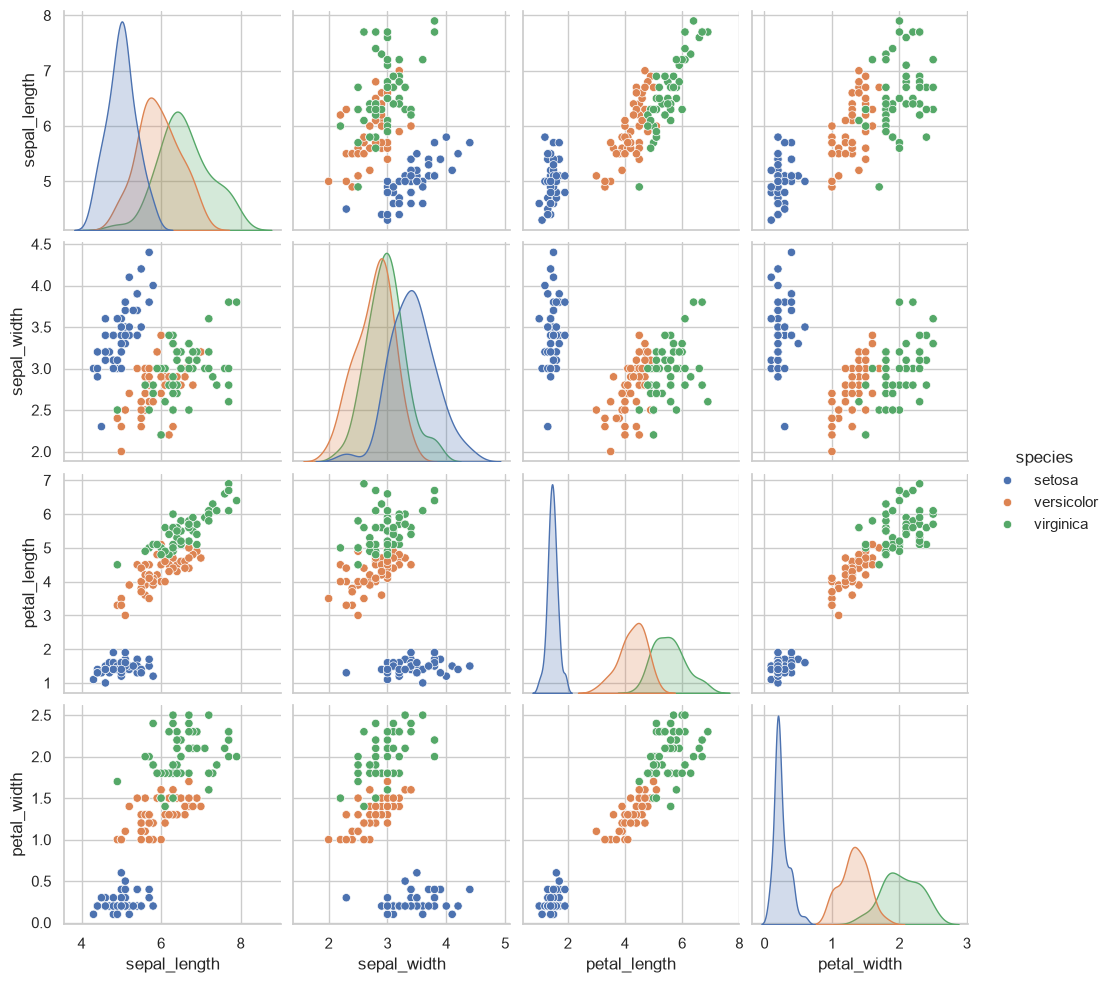

In [5]:
sns.pairplot(iris, hue="species")

plt.show()

Read what it just told you. The petal measurements separate the three species almost perfectly — look at any panel involving `petal_length` and you see three distinct clumps. The sepal measurements overlap much more.

That is a real finding, and you got it in one line before writing a single question of your own. Much later in the course, when a classifier tells you petal length is the important feature, this is the picture behind it.

One warning: `pairplot` draws every pair, so it gets slow and unreadable past about eight numeric columns. Pick your columns first on a wide table.

## Step 3 — `heatmap` of the correlations

The pair plot showed relationships as pictures. A **correlation matrix** puts a number on each one, from -1 (as one goes up the other goes down) through 0 (no straight-line relationship) to +1 (they move together exactly).

pandas computes it and seaborn colours it.

In [6]:
corr = iris.corr(numeric_only=True)

corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


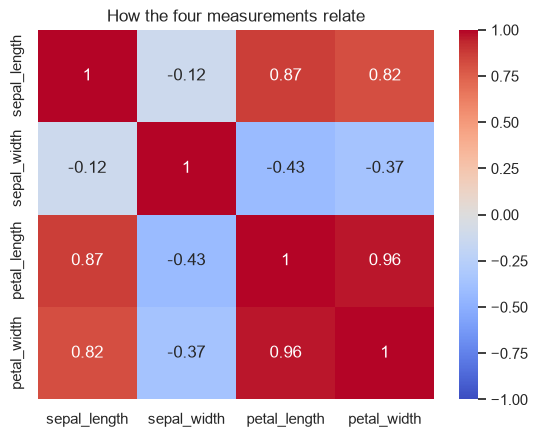

In [7]:
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("How the four measurements relate")
plt.show()

`petal_length` and `petal_width` score 0.96 — nearly the same measurement twice. `sepal_width` is mildly negative against everything else, which is why it was the column that did not separate the species in the pair plot.

`vmin=-1, vmax=1` pins the colour scale so that white always means zero. Without it the colours stretch to fit whatever range is present and a weak correlation can look dramatic — the first of today's honesty rules.

## Step 4 — making a chart presentable

Everything so far used seaborn's defaults. Four adjustments turn a working chart into one you would show someone:

1. `sns.set_theme(style=...)` — the overall look. Try `whitegrid`, `darkgrid`, `white`, `ticks`.
2. `plt.figure(figsize=(w, h))` — the size, in inches. Call it **before** the chart.
3. `palette=` — the colours. `deep`, `muted`, `pastel`, `Set2`, `viridis`.
4. A real title and real axis labels. A column name is not a label.

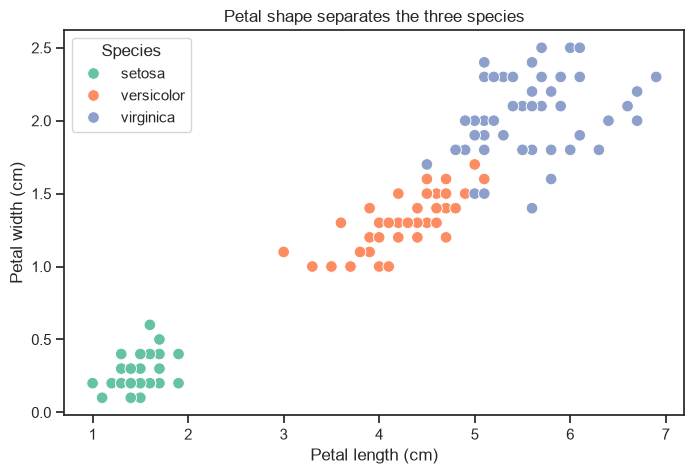

In [8]:
sns.set_theme(style="ticks")
plt.figure(figsize=(8, 5))

ax = sns.scatterplot(data=iris, x="petal_length", y="petal_width",
                     hue="species", palette="Set2", s=70)

ax.set_title("Petal shape separates the three species")
ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.legend(title="Species")

plt.show()

# Put the theme back for the rest of the notebook.
sns.set_theme(style="whitegrid")

Read that title again. It does not say "petal length vs petal width" — the axes already say that. It says what the chart **means**. A title is the one sentence you want remembered.

## Step 5 — four charts on one page

A dashboard is several charts sharing a page so they can be read together. `plt.subplots` makes the grid, and every seaborn function takes an `ax=` argument saying which panel to draw into.

Four questions, four panels:

1. How big do the petals get, species by species?
2. What shape is the sepal length column?
3. Do petal length and width move together?
4. How many flowers of each species?

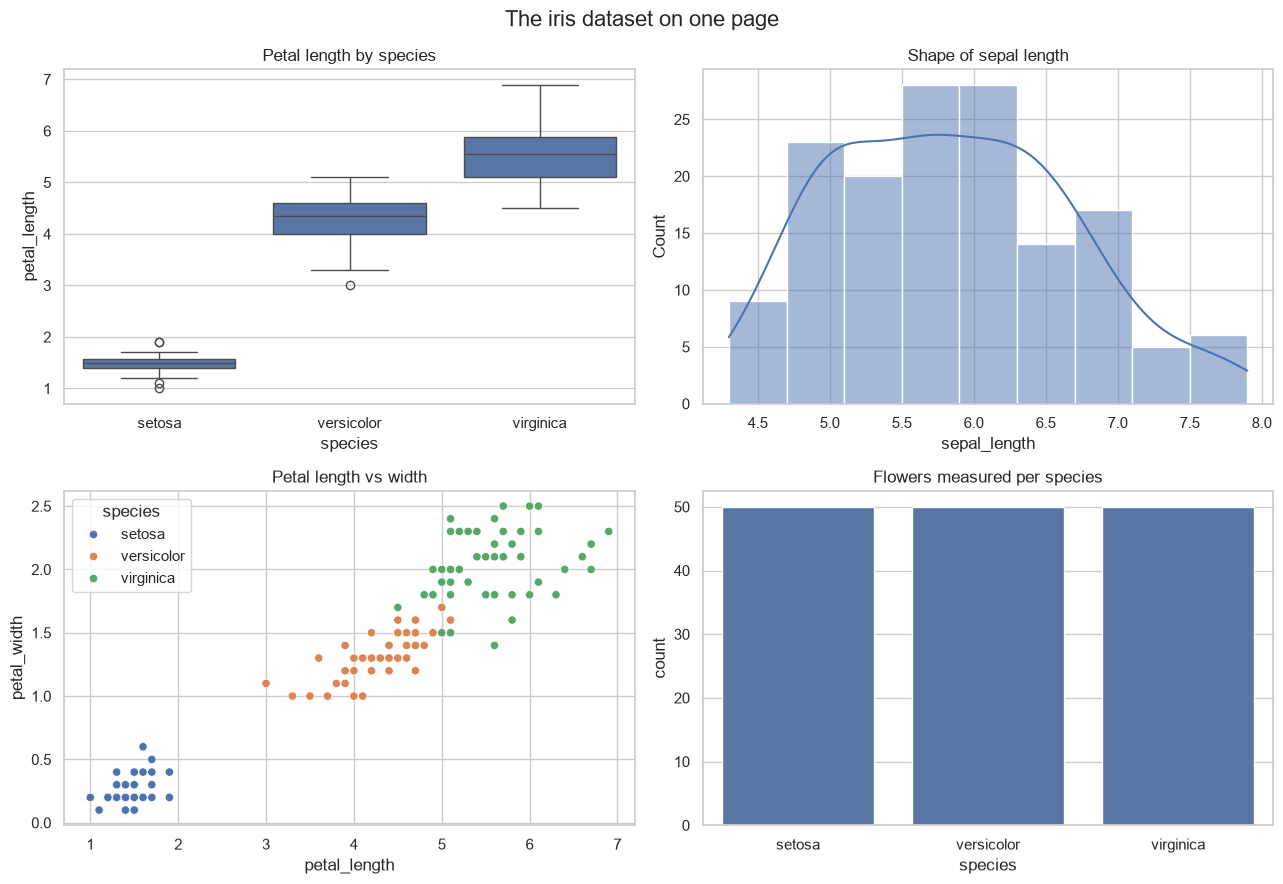

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1 (top-left): compare categories -> box
sns.boxplot(data=iris, x="species", y="petal_length", ax=axes[0, 0])
axes[0, 0].set_title("Petal length by species")

# Panel 2 (top-right): shape of one column -> histogram
sns.histplot(data=iris, x="sepal_length", kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Shape of sepal length")

# Panel 3 (bottom-left): two numbers -> scatter
sns.scatterplot(data=iris, x="petal_length", y="petal_width",
                hue="species", ax=axes[1, 0])
axes[1, 0].set_title("Petal length vs width")

# Panel 4 (bottom-right): how many -> count
sns.countplot(data=iris, x="species", ax=axes[1, 1])
axes[1, 1].set_title("Flowers measured per species")

fig.suptitle("The iris dataset on one page", fontsize=16)
fig.tight_layout()
plt.show()

`tight_layout()` is the line that stops the titles and labels colliding. Forget it and your panels overlap — it is the single most common complaint about a first dashboard.

## Step 6 — the honest sentence

A chart with no sentence attached is decoration. For each panel, write the one thing it shows. If you cannot write the sentence, the chart is not earning its place on the page.

For the dashboard above:

1. Petal length separates the species cleanly; setosa barely overlaps the other two.
2. Sepal length is roughly symmetric around 5.8 cm, with no long tail.
3. Petal length and width rise together almost in lockstep.
4. The dataset is balanced — 50 flowers of each species, so no species is over-represented.

### One honesty rule before you go

Bars must start at zero. A bar chart works because the eye compares **lengths**, so cutting the axis makes a small difference look huge. Run the next cell and see the same two numbers tell two different stories.

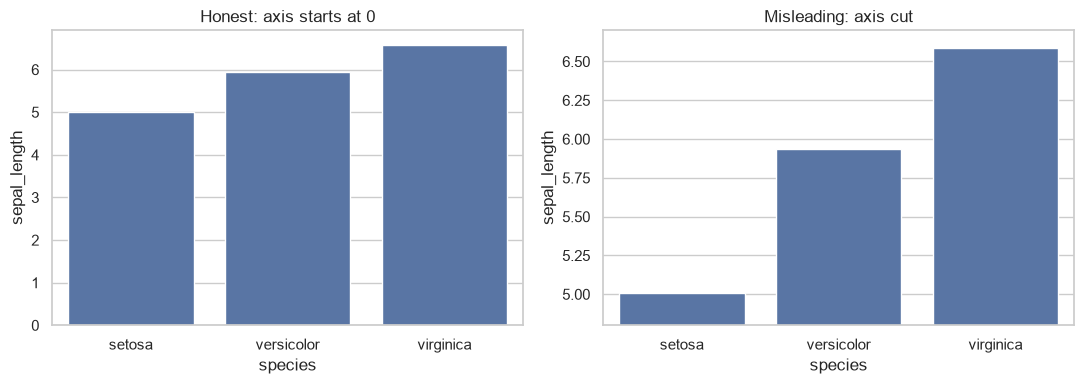

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

means = iris.groupby("species")["sepal_length"].mean().reset_index()

# Honest: the axis starts at zero.
sns.barplot(data=means, x="species", y="sepal_length", ax=axes[0])
axes[0].set_title("Honest: axis starts at 0")

# Misleading: the same numbers, axis cut to make gaps look enormous.
sns.barplot(data=means, x="species", y="sepal_length", ax=axes[1])
axes[1].set_ylim(4.8, 6.7)
axes[1].set_title("Misleading: axis cut")

fig.tight_layout()
plt.show()

Identical data. The right-hand chart makes a 15% difference look like a tenfold one. You will see this in news graphics and in pitch decks, and now you will catch it.

## Your deliverable

This closes Module 0. Build a **one-page dashboard of your own**:

1. Pick `tips`, `flights`, or any CSV of your own.
2. Write down **four questions** first, in plain English, before you draw anything.
3. Choose the chart that answers each — use the table below.
4. Lay them out with `plt.subplots`, give every panel a real title and real axis labels.
5. Write the one honest sentence under each panel.

| You want to show | Chart |
|---|---|
| Compare categories | `barplot` |
| Trend over time | `lineplot` |
| Shape of one column | `histplot` / `boxplot` |
| Relationship between two | `scatterplot` / `regplot` |
| How many in each category | `countplot` |
| A grid of numbers | `heatmap` |

Marked on: does each chart answer its question, is the axis honest, and is the page readable without you there to explain it.

In [11]:
# Your dashboard here.
#
# My four questions:
#   1.
#   2.
#   3.
#   4.

### Stretch (optional)

`sns.set_context()` scales every font and line at once — use `"talk"` for a projector and `"paper"` for a report. And `fig.savefig` writes the page out as a file to drop into a slide deck or email.

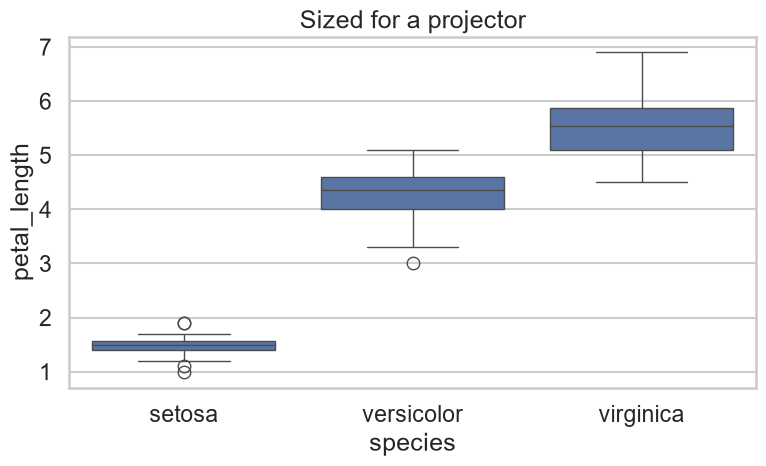

In [12]:
sns.set_context("talk")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=iris, x="species", y="petal_length", ax=ax)
ax.set_title("Sized for a projector")
fig.tight_layout()

# fig.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

sns.set_context("notebook")